In [1]:
import pysam
import pandas as pd
import numpy as np
import os
import pygenomeviz
from Bio.Seq import Seq
from Bio import SeqIO
import re
from pygenomeviz import GenomeViz

In [2]:
import matplotlib as mpl

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"], 
    
})
mpl.rcParams['pdf.compression'] = 9        
mpl.rcParams['path.simplify'] = True        
mpl.rcParams['path.simplify_threshold'] = 1.0  

In [3]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [4]:
orderDF = pd.read_csv("/LeeLab/Tools_and_Scripts/DavidPorubsky/Pille_HPRC/sample_order.txt",sep='\t')
OrderDict={x:y for x,y in zip(orderDF['Order'], orderDF['ID'])}

In [5]:
vals = list(OrderDict.values())
samplePairs = [(vals[i], vals[i+1]) for i in range(len(vals)-1)]

In [6]:
assemblyDict={}
directory='/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split(".")[0]]= directory+file
print(len(assemblyDict))

145


In [7]:
ColorDict={'DYZ18_Yq':'#FC9D2B', 'Yqhet_3k1bp':'#03EDF9','Yqhet_2k7bp':'#239902','DYZ1_Yq':'#BABABA','DYZ2_Con':'#0552A5'}

In [8]:
genome_list = []
filesToVisualize =[]
directory='/LeeLab/Tools_and_Scripts/DavidPorubsky/Pille_HPRC/'
for file in os.listdir(directory):
    if '.bed' in str(file):
        print(file)
        
        if '.bed' in (file) and 'T2T' not in file:
            sampleName = file.split("_")[1]
        elif 'bed' in file:
            sampleName = 'T2TY'
        
        else:
            sampleName ='test'

        hmmerDF1 = pd.read_csv(assemblyDict[sampleName])
        hmmerDF = hmmerDF1[hmmerDF1['0']==sampleName+"_chrY"].copy()
        hmmerDF['Color'] = [ColorDict[x] for x in hmmerDF['1']]

        preDF = pd.read_csv(directory+file, header=None)
        firstList=[]
        for row in preDF[0]:
            firstList.append(row.split())
            
        df1 = pd.DataFrame(data=firstList)
        
        df2 = df1.copy()

        newDFList=[]
        for row in df2.index:
            contig = df2.at[row,0]
            start = int(df2.at[row,1])
            end = int(df2.at[row,2])
            name = df2.at[row,3]
            color = df2.at[row,4]
            newDFList.append([contig, start, end, name, color])
        
        for row in hmmerDF.index:
            contig = hmmerDF.at[row,'0']
            start = int(hmmerDF.at[row,'3'])
            end = int(hmmerDF.at[row,'4'])
            name = hmmerDF.at[row,'1']
            color = hmmerDF.at[row,'Color']
            newDFList.append([contig, start, end, name, color])
        
        df = pd.DataFrame(data=newDFList).sort_values(by=[1])

        filesToVisualize.append(sampleName)
        df['NewStart']='NONE'
        df['NewEnd']='NONE'

        flag=0
        for row in df.index:
            if flag==0:
                previousStart = int(df.at[row,1])
                previousEnd = int(df.at[row,2])
                df.at[row,'NewStart'] = previousStart
                df.at[row,'NewEnd'] = previousEnd
                flag+=1
            else:
                currentStart = int(df.at[row,1])
                currentEnd = int(df.at[row,2])
                df.at[row,'NewStart'] = previousEnd
                df.at[row,'NewEnd'] = currentEnd
        
                previousStart = int(df.at[row,1])
                previousEnd = int(df.at[row,2])
        
        start=1
        features2=()
        for row in df.index:
            length = (df.at[row,'NewEnd'] - df.at[row,'NewStart'])+1
            features2 = add_feature(features2, (df.at[row,'NewStart'], df.at[row,'NewEnd'], 1, df.at[row,4]))
            
        totalsize= (max(df['NewEnd'])+1)
        genome_list.append(dict(name=sampleName, size=totalsize, features=features2))

11_HG02392_chrY_SeqCl_PH.bed
08_NA20905_chrY_SeqCl_PH.bed
02_HG01890_chrY_SeqCl_PH.bed
05_NA18983_chrY_SeqCl_PH.bed
04_HG03225_chrY_SeqCl_PH.bed
12_HG00512_chrY_SeqCl_PH.bed
09_HG00290_chrY_SeqCl_PH.bed
06_HG03065_chrY_SeqCl_PH.bed
13_HG03732_chrY_SeqCl_PH.bed
01_HG02984_chrY_SeqCl_PH.bed
10_NA18608_chrY_SeqCl_PH.bed
07_HG002_chrY_SeqCl_PH.bed
03_HG02666_chrY_SeqCl_PH.bed
14_HG00642_chrY_SeqCl_PH.bed


In [9]:
gv = GenomeViz(fig_track_height=.35, feature_track_ratio=0.5)
gv.set_scale_xticks(ymargin=0.5)
used = {}
trackSizesDict={}
for sample in OrderDict.values():
    FontColorToUse = 'black'

    if sample in filesToVisualize:
        print(sample)
        used[sample] = 1

        for genome in genome_list:
            if sample == genome['name']:
                used[genome['name']] = 1

                name, size, features = genome["name"], genome["size"], genome["features"]

                track_size = [int(size)]
                trackSizesDict[name]=size

                track = gv.add_feature_track(
                    f"{name}",
                    track_size,
                    labelsize=10,
                    label_kws={"color": FontColorToUse},
                )

                for idx, feature in enumerate(features, 1):
                    start, end, strand, color = feature
                    track.add_feature(int(start), int(end), strand, plotstyle="bigbox", facecolor=color)

HG02984
HG01890
HG02666
HG03225
NA18983
HG03065
HG002
NA20905
HG00290
NA18608
HG02392
HG00512
HG03732
HG00642


In [10]:
_CIGAR_RE = re.compile(r"(\d+)([MIDNSHP=X])")

def _parse_tags(fields):
    tags = {}
    for f in fields[12:]:
        parts = f.split(":", 2)
        if len(parts) == 3:
            k, t, v = parts
            tags[k] = (t, v)
    return tags

def _parse_cigar(cg):
    return [(int(n), op) for n, op in _CIGAR_RE.findall(cg)]

def read_paf(paf_path, win=100_000, min_keep=10_000):
    """
    Parse a PAF and split each alignment into <=win bp windows along the QUERY,
    using cg:Z: CIGAR to track query/target coordinates. Windows <win are kept
    only if >= min_keep.

    Output columns:
      contig, start, end, strand, contig_len,
      matching_contig, matching_start, matching_end, matching_len,
      n_match, aln_len, pct_identity
    """
    rows = []
    with open(paf_path) as fh:
        for line in fh:
            if not line.strip() or line.startswith("#"):
                continue
            p = line.rstrip("\n").split("\t")
            if len(p) < 12:
                continue

            qname  = p[0]
            qlen   = int(p[1])
            qstart = int(p[2])
            qend   = int(p[3])
            strand = p[4]      
            tname  = p[5]
            tlen   = int(p[6])
            tstart = int(p[7])
            tend   = int(p[8])
            nmatch_tot = int(p[9])
            alnlen_tot = int(p[10])

            tags = _parse_tags(p)
            cg = tags.get("cg", (None, None))[1] if tags.get("cg", (None, None))[0] == "Z" else None

            nm = None
            if "NM" in tags and tags["NM"][0] == "i":
                try:
                    nm = int(tags["NM"][1])
                except ValueError:
                    nm = None

            def global_pct_identity():
                if alnlen_tot <= 0:
                    return float("nan")
                if nm is not None:
                    return 100.0 * (1.0 - (nm / alnlen_tot))
                return 100.0 * (nmatch_tot / alnlen_tot)

            if not cg:
                q_span = qend - qstart
                if q_span >= min_keep:
                    rows.append({
                        "contig": qname, "start": qstart, "end": qend, "strand": strand, "contig_len": qlen,
                        "matching_contig": tname,
                        "matching_start": min(tstart, tend),
                        "matching_end":   max(tstart, tend),
                        "matching_len": tlen,
                        "n_match": nmatch_tot,
                        "aln_len": alnlen_tot,
                        "pct_identity": global_pct_identity()
                    })
                continue

            ops = _parse_cigar(cg)
            use_eqx = any(op in ("=", "X") for _, op in ops)

            qpos = qstart
            tpos = tend if strand == "-" else tstart

            win_start_q = qstart
            win_end_q = win_start_q + win

            n_match_w = x_mis_w = ins_w = del_w = aln_len_w = m_unknown_w = 0
            t_span_started = False
            t_start_w = None
            t_last_pos = None

            prop_match_global = (nmatch_tot / alnlen_tot) if alnlen_tot > 0 else 0.0
            if nm is not None and alnlen_tot > 0:
                prop_match_global = max(0.0, 1.0 - (nm / alnlen_tot))

            def flush_window():
                nonlocal n_match_w, x_mis_w, ins_w, del_w, aln_len_w, m_unknown_w
                nonlocal t_span_started, t_start_w, t_last_pos, win_start_q

                qwin_len = qpos - win_start_q
                if qwin_len >= win or (min_keep <= qwin_len < win):
                    if use_eqx:
                        nmatch_final = n_match_w
                        edits = x_mis_w + ins_w + del_w
                    else:
                        nmatch_final = int(round(aln_len_w * prop_match_global))
                        edits = max(0, aln_len_w - nmatch_final)

                    denom = nmatch_final + edits
                    pct_ident = 100.0 * (nmatch_final / denom) if denom > 0 else float("nan")

                    if t_span_started and t_last_pos is not None:
                        ts = min(t_start_w, t_last_pos)
                        te = max(t_start_w, t_last_pos)
                    else:
                        ts = te = tpos

                    rows.append({
                        "contig": qname,
                        "start": win_start_q,
                        "end": qpos,
                        "strand": strand,
                        "contig_len": qlen,
                        "matching_contig": tname,
                        "matching_start": ts,
                        "matching_end": te,
                        "matching_len": tlen,
                        "n_match": nmatch_final,
                        "aln_len": aln_len_w,
                        "pct_identity": pct_ident
                    })

                win_start_q = qpos
                n_match_w = x_mis_w = ins_w = del_w = aln_len_w = m_unknown_w = 0
                t_span_started = False
                t_start_w = None
                t_last_pos = None

            for length, op in ops:
                remain = length
                while remain > 0:
                    q_room = max(0, win_end_q - qpos)

                    if op in ("M", "=", "X", "I", "S"):
                        step_q = remain if q_room == 0 else min(remain, q_room)
                        step_t = step_q if op in ("M", "=", "X") else 0

                        if step_t > 0:
                            if not t_span_started:
                                t_start_w = tpos
                                t_span_started = True
                            tpos = (tpos - step_t) if strand == "-" else (tpos + step_t)
                            t_last_pos = tpos

                        qpos += step_q

                        if op == "=":
                            n_match_w += step_q; aln_len_w += step_q
                        elif op == "X":
                            x_mis_w  += step_q; aln_len_w += step_q
                        elif op == "M":
                            m_unknown_w += step_q; aln_len_w += step_q
                        elif op == "I":
                            ins_w += step_q;   aln_len_w += step_q
                        elif op == "S":
                            pass

                        remain -= step_q

                    elif op in ("D", "N"):
                        step_t = remain
                        if step_t > 0:
                            if not t_span_started:
                                t_start_w = tpos
                                t_span_started = True
                            tpos = (tpos - step_t) if strand == "-" else (tpos + step_t)
                            t_last_pos = tpos
                            del_w += step_t
                            aln_len_w += step_t
                        remain = 0

                    elif op in ("H", "P"):
                        remain = 0

                    if qpos == win_end_q:
                        flush_window()
                        win_end_q += win

            if (qpos - win_start_q) > 0:
                flush_window()

    df = pd.DataFrame.from_records(rows, columns=[
        "contig","start","end","strand","contig_len",
        "matching_contig","matching_start","matching_end","matching_len",
        "n_match","aln_len","pct_identity"
    ])

    if not df.empty:
        int_cols = ["start","end","contig_len","matching_start","matching_end","matching_len","n_match","aln_len"]
        for c in int_cols:
            df[c] = pd.to_numeric(df[c], downcast="integer", errors="coerce")
        df["pct_identity"] = pd.to_numeric(df["pct_identity"], errors="coerce")

    return df


In [11]:
directory='/LeeLab/Tools_and_Scripts/DavidPorubsky/Pille_HPRC/'
for file in os.listdir(directory):
    if '.paf' in str(file):
        print(file)
        if 'pair' in file:
            startSample = str(file).split("pair-")[1].split("_")[0]
            endSample = str(file).split("pair-")[1].split("-to-")[1].split("_")[0]
        else:
            startSample = str(file).split("-")[1]
            endSample = str(file).split("-")[3]

        df = read_paf(os.path.join(directory, file)).sort_values(by=['start'])
        df = df[df['pct_identity'] >= 90] 
        bins = [95, 99, 99.5, 99.6, 99.7, 99.8, 99.9, float("inf")]
        colors = ['#cdded5', '#dbe2c4', '#ede5a6', '#f1d785', '#f4c481', '#f6ae80', '#f88c7f']

        
        df['Color'] = pd.cut(df['pct_identity'], bins=bins, labels=colors)
        df['Color'] = df['Color'].astype(str).replace("nan", "black")

        for _, row in df.iterrows():

            if row['strand'] == '+':

                gv.add_link(
                    (startSample, int(row['start']), int(row['end'])),
                    (endSample,   int(row['matching_start']), int(row['matching_end'])),
                    color=str(row['Color']),
                    inverted_color=str(row['Color']),
                    curve=True,
                    ignore_outside_range=True,   
                    size=0.8
                )
            else:
                gv.add_link(
                    (startSample, int(row['start']), int(row['end'])),
                    (endSample,   int(row['matching_end']), int(row['matching_start'])),
                    color=str(row['Color']),
                    inverted_color=str(row['Color']),
                    curve=True,
                    ignore_outside_range=True,
                    size=0.8
                )

06-pair-HG002_chrY-to-HG03065_chrY-mm2_chrY-Verkko_161025.paf
12-pair-HG03732_chrY-to-HG00512_chrY-mm2_chrY-Verkko_161025.paf
04-pair-NA18983_chrY-to-HG03225_chrY-mm2_chrY-Verkko_161025.paf
13-pair-HG00642_chrY-to-HG03732_chrY-mm2_chrY-Verkko_161025.paf
10-pair-HG02392_chrY-to-NA18608_chrY-mm2_chrY-Verkko_161025.paf
08-pair-HG00290_chrY-to-NA20905_chrY_1contig-mm2_chrY-Verkko_161025.paf
09-pair-NA18608_chrY-to-HG00290_chrY-mm2_chrY-Verkko_161025.paf
03-pair-HG03225_chrY-to-HG02666_chrY-mm2_chrY-Verkko_161025.paf
11-pair-HG00512_chrY-to-HG02392_chrY-mm2_chrY-Verkko_161025.paf
05-pair-HG03065_chrY-to-NA18983_chrY-mm2_chrY-Verkko_161025.paf
01-pair-HG01890_chrY_1contig-to-HG02984_chrY_1contig-mm2_chrY-Verkko_161025.paf
02-pair-HG02666_chrY-to-HG01890_chrY_1contig-mm2_chrY-Verkko_161025.paf
07-pair-NA20905_chrY_1contig-to-HG002_chrY-mm2_chrY-Verkko_161025.paf


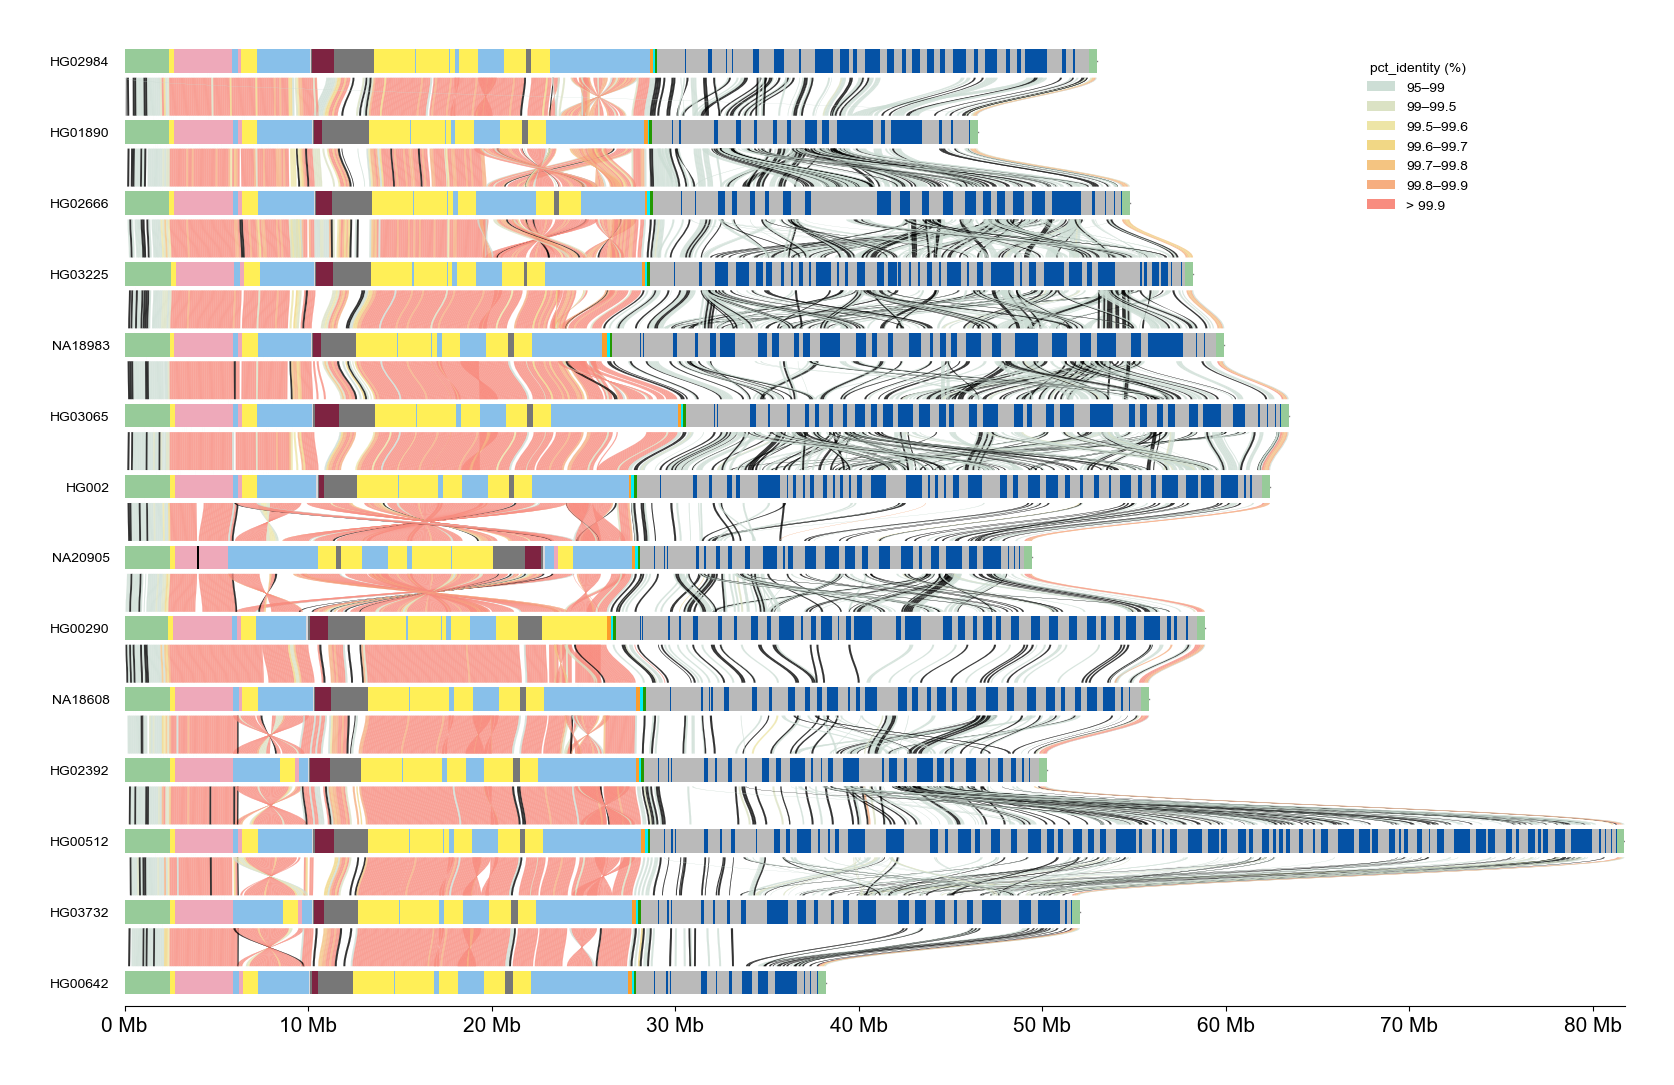

In [12]:
from matplotlib.patches import Patch

bins = [95, 99, 99.5, 99.6, 99.7, 99.8, 99.9, float("inf")]
colors = ['#cdded5', '#dbe2c4', '#ede5a6', '#f1d785', '#f4c481', '#f6ae80', '#f88c7f']
labels = []
for i in range(len(colors)):
    lo, hi = bins[i], bins[i+1]
    labels.append((f"≤ {hi:g}" if lo == -float("inf")
                   else f"> {lo:g}" if hi == float("inf")
                   else f"{lo:g}–{hi:g}"))
handles = [Patch(facecolor=c, edgecolor="none", label=lab) for c, lab in zip(colors, labels)]

fig = gv.plotfig()              
fig.subplots_adjust(right=0.80) 
fig.legend(handles=handles, title="pct_identity (%)",
           loc="upper left", bbox_to_anchor=(0.82, 1.0), frameon=False)
fig.savefig("/Y-Assemblies100kbp_200dpi_90.pdf", bbox_inches="tight")
fig.savefig("/Y-Assemblies100kbp_200dpi_90.jpeg", dpi=200, bbox_inches="tight")